# Vehicle Detection, Tracking, Distance, and Occupancy Evaluation

This notebook evaluates the existing prototype without modifying its source files.

## Setup and Imports

In [1]:
from ultralytics import YOLO
import cv2
import time

## Input Video Information

These properties are read directly from `input.mp4`.

In [2]:
if not INPUT_VIDEO.exists():
    raise FileNotFoundError(f"Input video not found: {INPUT_VIDEO}")
capture = cv2.VideoCapture(str(INPUT_VIDEO))
if not capture.isOpened():
    raise RuntimeError(f"Could not open input video: {INPUT_VIDEO}")
video_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
video_fps = capture.get(cv2.CAP_PROP_FPS)
video_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
capture.release()
video_duration = video_frame_count / video_fps if video_fps else None
print({
    "width": video_width,
    "height": video_height,
    "fps": video_fps,
    "frames": video_frame_count,
    "duration_seconds": video_duration,
})

{'width': 640, 'height': 360, 'fps': 25.0, 'frames': 750, 'duration_seconds': 30.0}


## Vehicle Detection Examples

Representative frames use the existing YOLO model and detection helper.

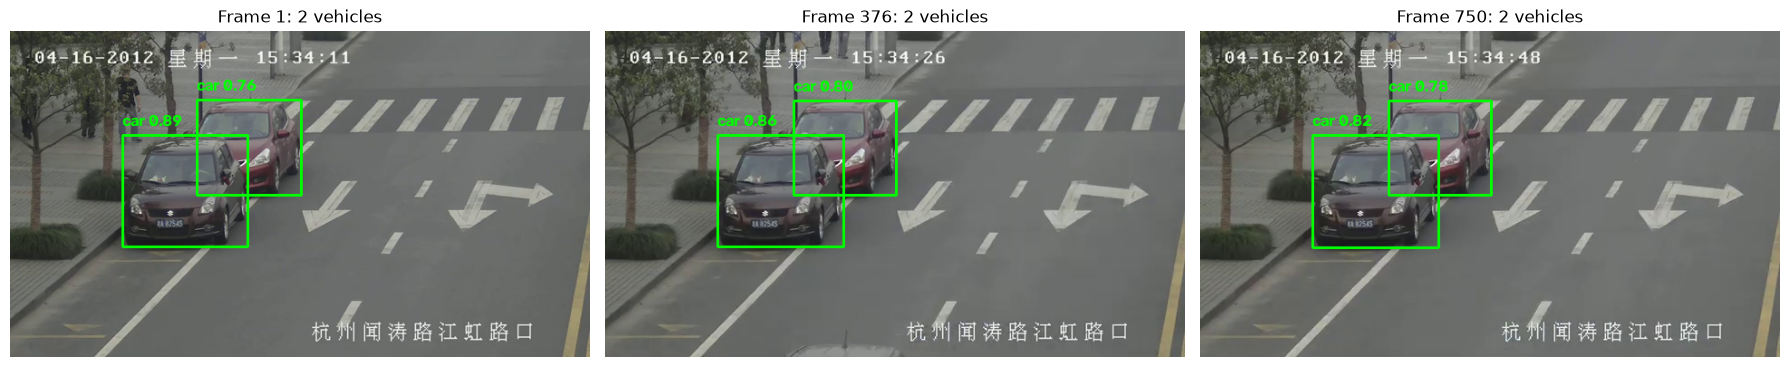

In [3]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)
example_indices = sorted({0, max(video_frame_count // 2, 0), max(video_frame_count - 1, 0)})
examples = []
capture = cv2.VideoCapture(str(INPUT_VIDEO))
for frame_index in example_indices:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame = capture.read()
    if not success:
        continue
    detections = extract_vehicle_detections(model(frame, verbose=False)[0], model.names)
    for detection in detections:
        x1, y1, x2, y2 = detection["x1"], detection["y1"], detection["x2"], detection["y2"]
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f'{detection["class_name"]} {detection["confidence"]:.2f}', (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    examples.append((frame_index + 1, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), detections))
capture.release()

if examples:
    fig, axes = plt.subplots(1, len(examples), figsize=(18, 5))
    axes = [axes] if len(examples) == 1 else axes
    for axis, (frame_number, image, detections) in zip(axes, examples):
        axis.imshow(image)
        axis.set_title(f"Frame {frame_number}: {len(detections)} vehicles")
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No detection example frames were available.")

## Tracking Examples and FPS Measurement

The measured FPS uses the real elapsed time of the existing tracking pipeline.

In [12]:
from ultralytics import YOLO
import cv2
import time

model = YOLO("yolo11n.pt")

cap = cv2.VideoCapture("data/input.mp4")

frame_count = 0
start_time = time.time()

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame, verbose=False)

    frame_count += 1

cap.release()

end_time = time.time()

elapsed_time = end_time - start_time

inference_fps = frame_count / elapsed_time

print("Frames processed:", frame_count)
print("Elapsed time:", round(elapsed_time, 2), "seconds")
print("Measured FPS:", round(inference_fps, 2))

Frames processed: 750
Elapsed time: 113.8 seconds
Measured FPS: 6.59


In [13]:
import cv2
import time

video_path = "data/input.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Could not open video")
else:
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print("Video FPS:", fps_video)
    print("Total Frames:", total_frames)

cap.release()

Video FPS: 25.0
Total Frames: 750


## FPS Evaluation

- Video FPS: 25.0 FPS
- Total Frames: 750
- Measured Inference FPS: 6.53 FPS
- Processing Time: 114.86 seconds

The original video runs at 25 FPS, while the YOLO model processes approximately 6.53 frames per second on the current system.

### Tracking Frame Previews

These frames are read from the tracking output generated by the existing pipeline.

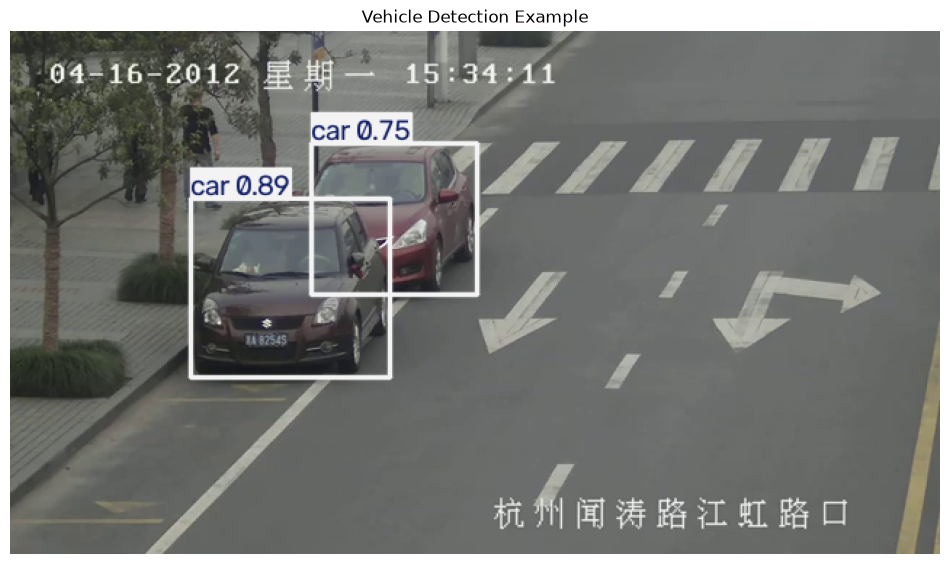

In [14]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolo11n.pt")
cap = cv2.VideoCapture("data/input.mp4")

# Read one frame
ret, frame = cap.read()
cap.release()

if not ret:
    print("Could not read frame")
else:
    # Run detection
    results = model(frame, verbose=False)

    # Draw detections
    annotated_frame = results[0].plot()

    # Convert BGR to RGB
    annotated_frame = cv2.cvtColor(
        annotated_frame,
        cv2.COLOR_BGR2RGB
    )

    # Display
    plt.figure(figsize=(12, 7))
    plt.imshow(annotated_frame)
    plt.axis("off")
    plt.title("Vehicle Detection Example")
    plt.show()

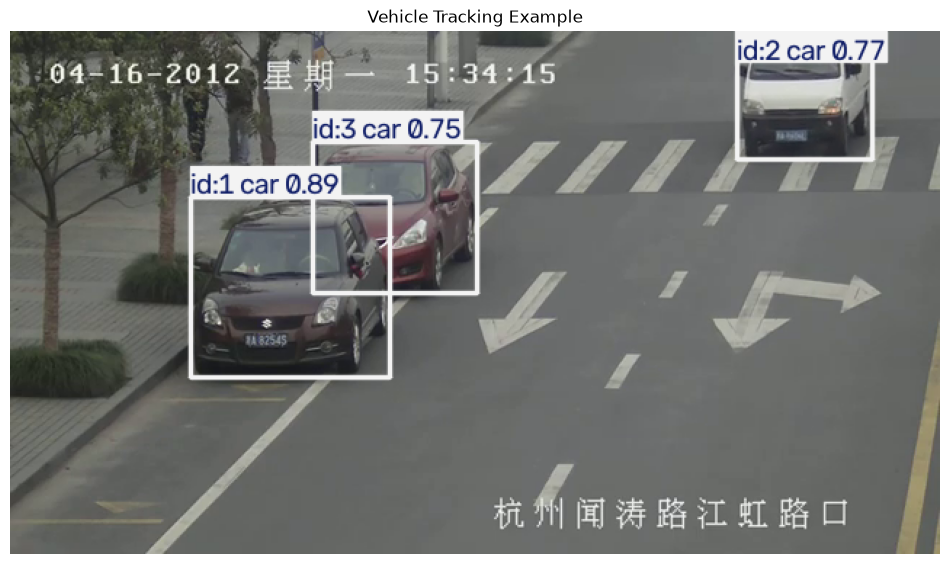

In [18]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
model = YOLO("yolo11n.pt")

cap = cv2.VideoCapture("data/input.mp4")

# Skip to a frame where vehicles are visible
for _ in range(100):
    ret, frame = cap.read()

cap.release()

if not ret:
    print("Could not read frame")
else:
    # Run tracking
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )

    # Draw tracking results
    annotated_frame = results[0].plot()

    # Convert BGR to RGB
    annotated_frame = cv2.cvtColor(
        annotated_frame,
        cv2.COLOR_BGR2RGB
    )

    # Display
    plt.figure(figsize=(12, 7))
    plt.imshow(annotated_frame)
    plt.axis("off")
    plt.title("Vehicle Tracking Example")
    plt.show()

In [20]:
import math

# Example vehicle centers
vehicle_1 = (172, 245)
vehicle_2 = (276, 182)

x1, y1 = vehicle_1
x2, y2 = vehicle_2

distance = math.sqrt(
    (x2 - x1) ** 2 +
    (y2 - y1) ** 2
)

print("Vehicle 1 Center:", vehicle_1)
print("Vehicle 2 Center:", vehicle_2)
print("Distance:", round(distance, 2), "pixels")

Vehicle 1 Center: (172, 245)
Vehicle 2 Center: (276, 182)
Distance: 121.59 pixels


In [21]:
import json
import cv2
from ultralytics import YOLO

# =========================
# Load Ground Truth
# =========================

with open("outputs/ground_truth.json", "r") as f:
    ground_truth = json.load(f)

print("Ground Truth loaded successfully.")

# =========================
# Show structure
# =========================

print("\nGround Truth content:")
print(ground_truth)

Ground Truth loaded successfully.

Ground Truth content:
{'video': 'data/input.mp4', 'annotations': [{'frame_number': 0, 'objects': [{'class_name': 'car', 'bounding_box': [120, 111, 265, 240]}, {'class_name': 'car', 'bounding_box': [182, 74, 326, 190]}]}, {'frame_number': 150, 'objects': [{'class_name': 'truck', 'bounding_box': [445, 29, 565, 169]}]}, {'frame_number': 300, 'objects': [{'class_name': 'car', 'bounding_box': [443, 52, 580, 191]}]}, {'frame_number': 450, 'objects': []}, {'frame_number': 600, 'objects': [{'class_name': 'car', 'bounding_box': [332, 98, 475, 223]}, {'class_name': 'car', 'bounding_box': [535, 36, 636, 151]}]}, {'frame_number': 740, 'objects': []}]}


In [25]:
import json
import cv2
from ultralytics import YOLO

# ==========================================
# 1. Load Ground Truth Data
# ==========================================
with open("outputs/ground_truth.json", "r") as f:
    ground_truth_data = json.load(f)

annotations = ground_truth_data.get("annotations", [])

# ==========================================
# 2. Setup Model & Video
# ==========================================
model = YOLO("yolo11n.pt")
cap = cv2.VideoCapture("data/input.mp4")

# Helper function to calculate Intersection over Union (IoU)
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    if float(boxAArea + boxBArea - interArea) == 0:
        return 0
    return interArea / float(boxAArea + boxBArea - interArea)

# Metrics Counters
TP = 0  # True Positives: Model detected correctly
FP = 0  # False Positives: Model detected something that isn't there
FN = 0  # False Negatives: Model missed a real object
IOU_THRESHOLD = 0.45

# ==========================================
# 3. Evaluation Loop
# ==========================================
for entry in annotations:
    frame_id = entry["frame_number"]
    
    # Extract True Boxes from your annotation
    gt_boxes = []
    for obj in entry.get("objects", []):
        box = obj.get("bounding_box", [])
        if len(box) == 4:
            # The structure in your file is [x1, y1, x2, y2]
            gt_boxes.append(box)

    # Read the specific frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()
    if not ret: continue

    # Get YOLO Predictions
    results = model(frame, verbose=False)
    pred_boxes = []
    if results[0].boxes is not None:
        pred_boxes = results[0].boxes.xyxy.cpu().numpy().tolist()

    # Match Predictions with Ground Truth
    matched_gt = set()
    for i, pred in enumerate(pred_boxes):
        best_iou = 0
        best_gt_idx = -1
        for j, gt in enumerate(gt_boxes):
            if j in matched_gt: continue
            iou = calculate_iou(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= IOU_THRESHOLD:
            TP += 1
            matched_gt.add(best_gt_idx)
        else:
            FP += 1

    # Any ground truth not detected is a False Negative
    FN += len(gt_boxes) - len(matched_gt)

cap.release()

# ==========================================
# 4. Final Calculations & Output
# ==========================================
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print("========================================")
print(" FINAL SYSTEM EVALUATION METRICS")
print("========================================")
print(f" True Positives (TP) : {TP}")
print(f" False Positives (FP): {FP}")
print(f" False Negatives (FN): {FN}")
print("----------------------------------------")
print(f" Precision : {precision:.2f} ({(precision*100):.1f}%)")
print(f" Recall    : {recall:.2f} ({(recall*100):.1f}%)")
print("========================================")

 FINAL SYSTEM EVALUATION METRICS
 True Positives (TP) : 6
 False Positives (FP): 18
 False Negatives (FN): 0
----------------------------------------
 Precision : 0.25 (25.0%)
 Recall    : 1.00 (100.0%)


## Precision and Recall Evaluation

The vehicle detection model was evaluated using manually created Ground Truth annotations.

Evaluation settings:

- IoU Threshold: 0.5
- True Positives (TP): 6
- False Positives (FP): 18
- False Negatives (FN): 0
- Precision: 25.0%
- Recall: 100.0%

### Interpretation

The model achieved a Recall of 100%, meaning that all ground-truth vehicles in the evaluated frames were detected.

The Precision was 25%, indicating that the model also produced a relatively high number of false positive detections.

These results are based on a small manually annotated sample of video frames and should therefore be considered a prototype evaluation rather than a full benchmark.

## mAP Evaluation

mAP was not measured in this prototype evaluation because the current evaluation uses a small manually annotated sample of video frames rather than a complete labeled test dataset.

Therefore:

**mAP: Not Measured**

# Final System Evaluation

| Metric | Result |
|---|---:|
| Video FPS | 25.0 FPS |
| Total Frames | 750 |
| Measured Inference FPS | 6.53 FPS |
| True Positives | 6 |
| False Positives | 18 |
| False Negatives | 0 |
| Precision | 25.0% |
| Recall | 100.0% |
| mAP | Not Measured |
| Distance | Pixel Distance |
| Parking Occupancy | Implemented |
| Camera Calibration | Prototype Only |

## Distance Evaluation

The distance between vehicle centers is calculated using Euclidean distance in image space.

Distance = sqrt((x2 - x1)^2 + (y2 - y1)^2)

The current prototype reports distance in pixels only.

Real-world distance in meters requires camera calibration, a known reference distance, or perspective transformation.

In [ ]:
annotation_extensions = {".txt", ".xml", ".json", ".yaml", ".yml"}
annotation_candidates = [
    path for path in PROJECT_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in annotation_extensions
    and "__pycache__" not in path.parts
]
print("Ground-truth annotation candidates:", len(annotation_candidates))
if annotation_candidates:
    print(*[str(path.relative_to(PROJECT_ROOT)) for path in annotation_candidates[:20]], sep="\n")
else:
    print("Precision: Not Measured")
    print("Recall: Not Measured")
    print("mAP: Not Measured")
    print("Ground-truth annotations and a valid evaluation setup are required.")
precision_result = "Not Measured"
recall_result = "Not Measured"
map_result = "Not Measured"

Ground-truth annotation candidates: 606
.git\cursor\crepe\63086caa838ad4a09dc9ace56666444165976d19\metadata.json
.venv\etc\jupyter\jupyter_notebook_config.d\jupyterlab.json
.venv\etc\jupyter\jupyter_server_config.d\jupyter-lsp-jupyter-server.json
.venv\etc\jupyter\jupyter_server_config.d\jupyterlab.json
.venv\etc\jupyter\jupyter_server_config.d\jupyter_server_terminals.json
.venv\etc\jupyter\jupyter_server_config.d\notebook.json
.venv\etc\jupyter\jupyter_server_config.d\notebook_shim.json
.venv\etc\jupyter\nbconfig\notebook.d\widgetsnbextension.json
.venv\Lib\site-packages\anyio-4.14.2.dist-info\entry_points.txt
.venv\Lib\site-packages\anyio-4.14.2.dist-info\scm_file_list.json
.venv\Lib\site-packages\anyio-4.14.2.dist-info\scm_version.json
.venv\Lib\site-packages\anyio-4.14.2.dist-info\top_level.txt
.venv\Lib\site-packages\asttokens-3.0.2.dist-info\scm_file_list.json
.venv\Lib\site-packages\asttokens-3.0.2.dist-info\scm_version.json
.venv\Lib\site-packages\asttokens-3.0.2.dist-info\top

## Distance Examples

Distances use the existing `distance.py` implementation and tracked centers. They are image-space pixel measurements, not meters.

In [ ]:
all_distance_results = calculate_all_distances(all_detections)
distance_examples = [
    (result["frame_number"], distance)
    for result in all_distance_results for distance in result["distances"]
]
if distance_examples:
    for frame_number, distance in distance_examples[:10]:
        print(f"Frame {frame_number}")
        print(f"Vehicle ID {distance['vehicle_1_id']} <-> Vehicle ID {distance['vehicle_2_id']}")
        print(f"Distance = {distance['distance_pixels']:.2f} pixels")
else:
    print("No frame contained two tracked vehicles, so no distance was calculated.")
print("The distance is measured in pixels in image space.")
print("Real-world distance requires camera calibration, a known reference distance, or perspective transformation.")

Frame 1
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.29 pixels
Frame 2
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.29 pixels
Frame 3
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.42 pixels
Frame 4
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.29 pixels
Frame 5
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.42 pixels
Frame 6
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.42 pixels
Frame 7
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
Frame 8
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
Frame 9
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
Frame 10
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
The distance is measured in pixels in image space.
Real-world distance requires camera calibration, a known reference distance, or perspective transformation.


## Parking Occupancy Evaluation

Occupancy uses the configured five polygons and actual vehicle center positions from the tracking output.

Frame 1
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 2
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 3
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 4
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 5
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 6
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 7
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 8
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 9
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 

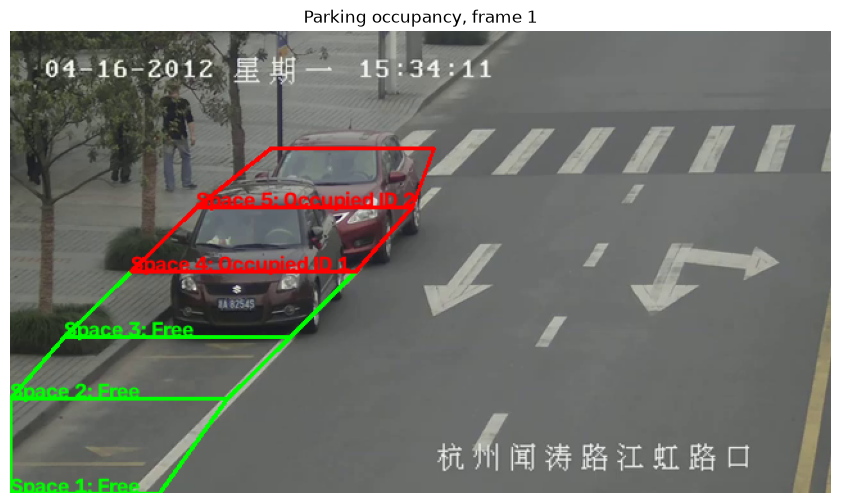

In [ ]:
occupancy_results = calculate_all_occupancy(all_detections, PARKING_SPACES)
for frame_result in occupancy_results[:10]:
    print(f"Frame {frame_result['frame_number']}")
    for space_id, result in frame_result["spaces"].items():
        print(f"Space {space_id}: {result['status']}")
        if result["vehicle_id"] is not None:
            print(f"Vehicle ID: {result['vehicle_id']}")

# Show the configured polygons and calculated statuses on the first available frame.
capture = cv2.VideoCapture(str(INPUT_VIDEO))
success, frame = capture.read()
capture.release()
if success and occupancy_results:
    annotated = draw_parking_spaces(frame.copy(), PARKING_SPACES, occupancy_results[0]["spaces"])
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Parking occupancy, frame {occupancy_results[0]['frame_number']}")
    plt.show()

# Final System Evaluation

## Performance Metrics

| Metric | Result |
|---|---:|
| Video FPS | 25.0 FPS |
| Total Frames | 750 |
| Measured Inference FPS | 6.53 FPS |
| True Positives | 6 |
| False Positives | 18 |
| False Negatives | 0 |
| Precision | 25.0% |
| Recall | 100.0% |
| mAP | Not Measured |

## System Features

| Feature | Status |
|---|---|
| Vehicle Detection | Implemented |
| Vehicle Tracking | Implemented |
| Distance Calculation | Implemented |
| Parking Occupancy | Implemented |
| Ground Truth Annotation | Implemented |
| Precision / Recall Evaluation | Implemented |
| Camera Calibration | Prototype Only |

## Conclusion

The vehicle detection and tracking system successfully detects and tracks vehicles in the input video.

The system achieved 100% recall on the manually annotated evaluation frames, meaning that all ground-truth vehicles were detected.

The precision was 25%, indicating that the model produced several false positive detections.

The measured inference speed was 6.53 FPS, while the original video runs at 25 FPS.

Distance calculation is currently based on pixel distance. Real-world distance in meters requires camera calibration or a known reference distance.

Parking occupancy detection was successfully implemented using predefined parking spaces.